In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2 # Used for Grad-CAM visualization
from sklearn.utils.class_weight import compute_class_weight
IMG_SIZE = 224
BATCH_SIZE = 32 
CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']
NUM_CLASSES = 4

In [2]:
TRAIN_DIR = 'archive\Training'
TEST_DIR = 'archive\Testing'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,        
    rotation_range=40,       
    width_shift_range=0.2,   
    height_shift_range=0.2,  
    zoom_range=0.2,          
    horizontal_flip=True,    
    fill_mode='nearest',
    validation_split=0.2 
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # <--- Match training preprocessing
)

# 3. Load Data from Directories
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=CLASSES
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, # Using the same directory with the 'validation' subset
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=CLASSES,
    shuffle=False # Keep shuffle=False for validation/testing
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False # Keep shuffle=False for validation/testing
)

print(f"Found {train_generator.samples} images for training.")
print(f"Found {validation_generator.samples} images for validation.")
print(f"Found {test_generator.samples} images for testing.")

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Found 4571 images for training.
Found 1141 images for validation.
Found 1311 images for testing.


In [3]:
# --- Custom Channel Attention Layer ---

class ChannelAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)

    def build(self, input_shape):

        self.channels = input_shape[-1]

        
        self.w = self.add_weight(name='attention_weights',
                                 shape=(self.channels,),
                                 initializer='ones', 
                                 trainable=True)
        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):
        # 1. Compute attention scores (alpha) using softmax
        alpha = tf.nn.softmax(self.w)

        # 2. Apply attention scores to the input vector (v_att = alpha * v)
        v_att = inputs * alpha
        return v_att

    def get_config(self):
        # Required for saving/loading the model
        config = super(ChannelAttention, self).get_config()
        return config

# --- 4. Model Building (VGG16 + BatchNorm + Fine-Tuning) ---
def build_optimized_vgg_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    
    # Load VGG16
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # --- Fine-Tuning Strategy ---
    # We unfreeze the last convolutional block (Block 5) to let it adapt
    # to MRI textures, while keeping earlier layers (edges/shapes) frozen.
    base_model.trainable = True
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == 'block5_conv1':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    inputs = base_model.input
    x = base_model.output

    # Attention & Pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = ChannelAttention(name='channel_attention')(x)
    
    # --- Classification Head Improvements ---
    # Adding BatchNormalization to stabilize training at high accuracy
    x = layers.BatchNormalization()(x) 
    x = layers.Dropout(0.4)(x) # Slightly reduced dropout
    
    x = layers.Dense(256, activation='relu')(x) # Increased density
    x = layers.BatchNormalization()(x) # Added another BatchNorm
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs, name='VGG16_Optimized')

model = build_optimized_vgg_model()
# Create the model
model = build_optimized_vgg_model()
model.summary() # Review the trainable/non-trainable params

Model: "VGG16_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pool                      │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ channel_attention (ChannelAttention) │ (None, 512)                 │             5

 Total params: 14,850,628 (56.65 MB)

 Trainable params: 7,213,828 (27.52 MB)

 Non-trainable params: 7,636,800 (29.13 MB)

In [5]:
# --- 5. Training Setup ---

# Optimizer: Small learning rate is crucial when fine-tuning
optimizer = keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Calculate weights to handle the imbalance (e.g., Meningioma vs Notumor)
class_indices = train_generator.classes
class_labels = np.unique(class_indices)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=class_indices
)
class_weights_dict = dict(zip(class_labels, class_weights))

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_vgg16_optimized.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print(f"\nStarting training with Image Size: {IMG_SIZE}x{IMG_SIZE}...")
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight=class_weights_dict
)


Starting training with Image Size: 224x224...
Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8211 - loss: 0.5080  
Epoch 1: val_accuracy improved from None to 0.56179, saving model to best_vgg16_optimized.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.8361 - loss: 0.4722 - val_accuracy: 0.5618 - val_loss: 1.1241 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8590 - loss: 0.4166  
Epoch 2: val_accuracy improved from 0.56179 to 0.72918, saving model to best_vgg16_optimized.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.8659 - loss: 0.3983 - val_accuracy: 0.7292 - val_loss: 0.7603 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8644 - loss: 0.3922  
Epoch 3: val_accuracy improved from 0.72918 to 0.78791, saving model to best_vgg16_optimized.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.8762 - loss: 0.3722 - val_accuracy: 0.7879 - val_l

Plotting training history...


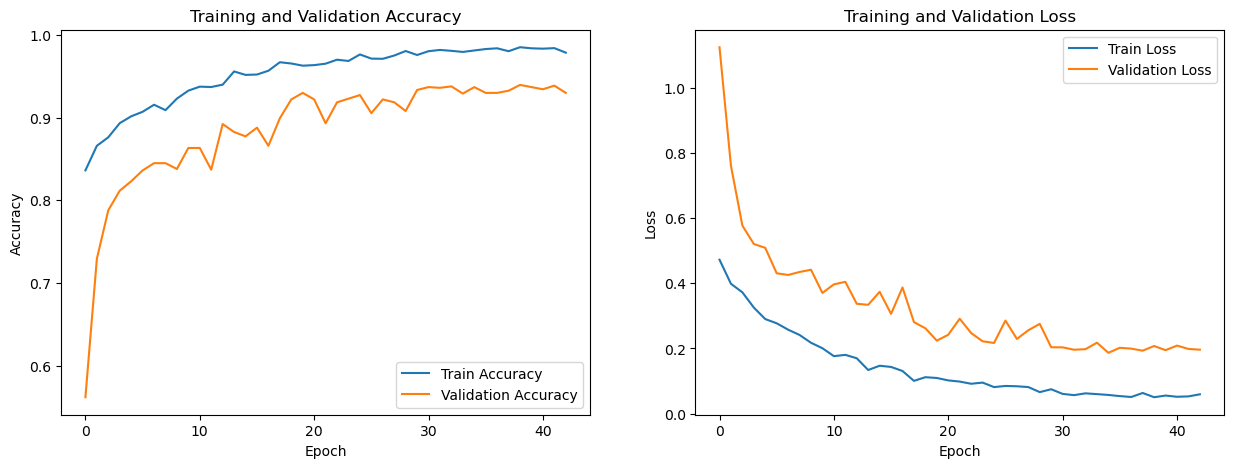

Evaluating model on test set...
Loading best model from: best_vgg16_optimized.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9626 - loss: 0.1036
Test Loss: 0.1036
Test Accuracy: 0.9626
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
Model prediction: notumor (Confidence: 94.48%)


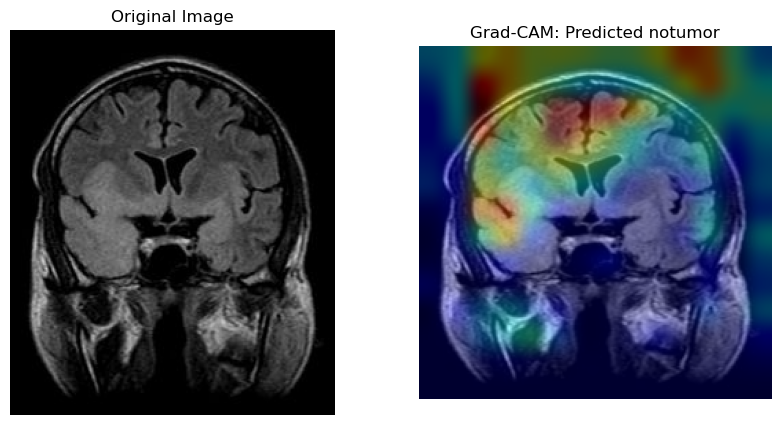

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input # <--- REQUIRED for correct visualization

# Assuming history, test_generator, and IMG_SIZE (224) are defined from the previous training cell

print("Plotting training history...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training & validation accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')

# Plot training & validation loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')

plt.show()

# --- 5b. Evaluate on Test Set ---
print("Evaluating model on test set...")

# --- Load the best OPTIMIZED saved model ---
# Updated filename to match the optimized training code
best_model_path = 'best_vgg16_optimized.keras' 
print(f"Loading best model from: {best_model_path}")

best_model = keras.models.load_model(
    best_model_path,
    custom_objects={'ChannelAttention': ChannelAttention} 
)

# ---------------------------------------------
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


# --- 5c. Grad-CAM Explainability ---

def get_img_array(img_path, size):
    """ Loads and preprocesses a single image. """
    img = keras.utils.load_img(img_path, target_size=size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0) # Add batch dimension
    
    # --- CRITICAL CHANGE ---
    # Previous: array = array / 255.0 
    # New: Use VGG16 specific preprocessing to match training data
    array = preprocess_input(array) 
    # -----------------------
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """ Generates the Grad-CAM heatmap. """
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
        
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    """ Overlays the heatmap on the original image. """
    # Load original image for display
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)
    
    # Use jet colormap
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Create image from heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)
    
    # Superimpose
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)
    return superimposed_img


# --- Run Grad-CAM ---
# Find the last convolutional layer name in VGG16 (Standard is 'block5_conv3')
last_conv_layer_name = "block5_conv3" 

# Ensure this path is correct on your system
IMAGE_PATH = 'archive/Testing/notumor/Te-no_0049.jpg' 

import os
if os.path.exists(IMAGE_PATH):
    # Prepare image
    img_array = get_img_array(IMAGE_PATH, size=(IMG_SIZE, IMG_SIZE))

    # Predict
    preds = best_model.predict(img_array)
    prediction_label = CLASSES[np.argmax(preds)]
    confidence = np.max(preds) * 100
    print(f"Model prediction: {prediction_label} (Confidence: {confidence:.2f}%)")

    # 3. Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, best_model, last_conv_layer_name)

    # 4. Display the results
    superimposed_img = display_gradcam(IMAGE_PATH, heatmap)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    # Convert BGR to RGB for correct color display
    plt.imshow(cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: Predicted {prediction_label}")
    plt.axis('off')

    plt.show()
else:
    print(f"Error: Image not found at {IMAGE_PATH}")


--- Generating Evaluation Metrics ---
Predicting on test data using 41 steps...
41/41 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.96      0.96       300
  meningioma       0.96      0.90      0.93       306
   pituitary       0.93      1.00      0.97       300
     notumor       0.99      0.98      0.99       405

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311


Confusion Matrix:
Confusion matrix plot saved as confusion_matrix.png

Calculating AUC/ROC...

Macro-average One-vs-Rest AUC score: 0.9983
ROC curve plot saved as roc_curves.png

--- Evaluation Metrics Generation Complete ---


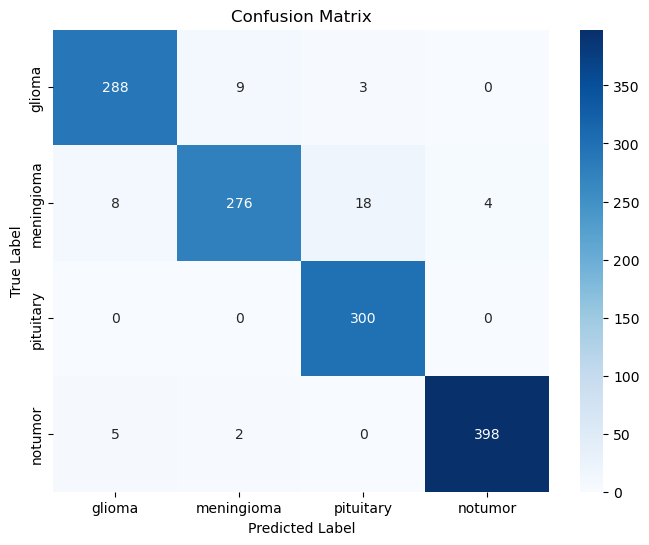

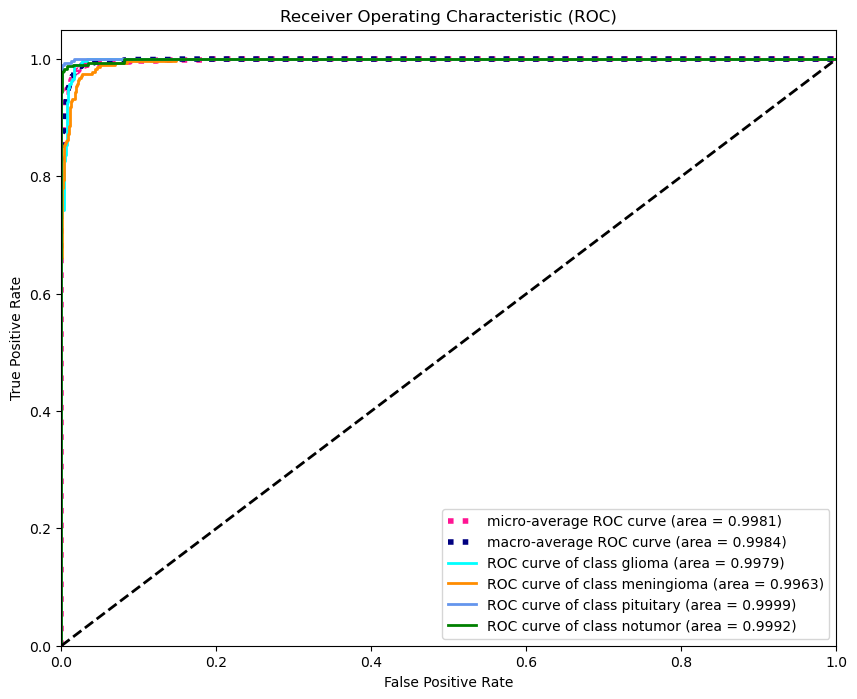

In [8]:
# --- 6. Model Evaluation Metrics ---
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle

print("\n--- Generating Evaluation Metrics ---")


test_generator.reset()

steps_per_epoch_test = int(np.ceil(test_generator.samples / test_generator.batch_size))

print(f"Predicting on test data using {steps_per_epoch_test} steps...")
y_pred_proba = best_model.predict(test_generator, steps=steps_per_epoch_test, verbose=1)


y_pred_proba = y_pred_proba[:test_generator.samples]

y_pred = np.argmax(y_pred_proba, axis=1)

y_true = test_generator.classes

y_true = y_true[:test_generator.samples]



class_labels = list(test_generator.class_indices.keys())

#Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png') # Save the plot
print("Confusion matrix plot saved as confusion_matrix.png")
# plt.show() # Use savefig instead of show

# AUC / ROC Curve
print("\nCalculating AUC/ROC...")

# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
# Finally average it and compute AUC
mean_tpr /= NUM_CLASSES
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Calculate OvR AUC Score using predicted probabilities
try:

    if y_true_bin.shape[0] != y_pred_proba.shape[0]:
         raise ValueError(f"Shape mismatch: y_true_bin {y_true_bin.shape} vs y_pred_proba {y_pred_proba.shape}")
    roc_auc_ovr = roc_auc_score(y_true_bin, y_pred_proba, multi_class='ovr', average='macro')
    print(f"\nMacro-average One-vs-Rest AUC score: {roc_auc_ovr:.4f}")
except ValueError as e:
    print(f"\nCould not calculate OvR AUC score directly: {e}")
    print("Using calculated macro-average AUC from ROC curves.")
    roc_auc_ovr = roc_auc["macro"] # Fallback

# Plot all ROC curves
plt.figure(figsize=(10, 8))

# Micro-average ROC
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.4f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

# Macro-average ROC
plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.4f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

# Individual class ROCs
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.4f})'
             ''.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('roc_curves.png') # Save the plot
print("ROC curve plot saved as roc_curves.png")
# plt.show() # Use savefig instead of show

print("\n--- Evaluation Metrics Generation Complete ---")